### H1V1 VACCINE PREDICTION ###
- By Andrew Nyakiba



 ## 1. Overview
- This project aims to build a classification model to predict whether an individual received the H1N1 vaccine based on demographic, behavioral, and health-related factors.

- The goal is to support public health organizations in identifying patterns in vaccination behavior and improving targeted interventions.

## 2. Business Understanding

- Vaccination is a key public health strategy, yet uptake remains inconsistent across populations.

**Stakeholder:** Public Health Organizations  
**Problem:** Low vaccination uptake  
**Goal:** Predict which individuals are likely to receive the H1N1 vaccine  

- By understanding the factors influencing vaccination, stakeholders can design targeted campaigns to improve vaccination rates.

## 3. Data Understanding

The dataset contains demographic, behavioral, and opinion-based features related to vaccination behavior.

Key observations:
- The dataset includes both categorical and numerical variables
- Several features contain missing values
- The target variable is binary (vaccinated vs not vaccinated)

**IMPORTING LIBRARIES**

In [228]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, recall_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc
from sklearn.tree import DecisionTreeClassifier

**LOADING DATASET**

In [229]:
# Load datasets
features = pd.read_csv('../data/training_set_features.csv')
labels = pd.read_csv('../data/training_set_labels.csv')

MERGING THE TWO DATASETS
- The two datasets will be merged together to produce one dataframe.
- The training set features dataset contains our input data
such as health behavior,age and employment status
- The training set labels dataset contains the target ()

In [230]:
# Merge datasets
df = features.merge(labels, on='respondent_id')


In [231]:
df.head()

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation,h1n1_vaccine,seasonal_vaccine
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN,0,0
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe,0,1
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo,0,0
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN,0,1
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb,0,0


In [232]:
#Finding the column names for our merged dataset
df.columns

Index(['respondent_id', 'h1n1_concern', 'h1n1_knowledge',
       'behavioral_antiviral_meds', 'behavioral_avoidance',
       'behavioral_face_mask', 'behavioral_wash_hands',
       'behavioral_large_gatherings', 'behavioral_outside_home',
       'behavioral_touch_face', 'doctor_recc_h1n1', 'doctor_recc_seasonal',
       'chronic_med_condition', 'child_under_6_months', 'health_worker',
       'health_insurance', 'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk',
       'opinion_h1n1_sick_from_vacc', 'opinion_seas_vacc_effective',
       'opinion_seas_risk', 'opinion_seas_sick_from_vacc', 'age_group',
       'education', 'race', 'sex', 'income_poverty', 'marital_status',
       'rent_or_own', 'employment_status', 'hhs_geo_region', 'census_msa',
       'household_adults', 'household_children', 'employment_industry',
       'employment_occupation', 'h1n1_vaccine', 'seasonal_vaccine'],
      dtype='object')

**Columns**

The dataset features/columns were grouped into meaningful categories to improve understanding and analysis:

- Demographic features (e.g., age, education, gender)
- Socioeconomic features (e.g., income, employment)
- Health-related features (e.g., chronic conditions, insurance)
- Behavioral features (e.g., hygiene practices, social behavior)
- Medical influence (e.g., doctor recommendations)
- Perception and opinion features (e.g., vaccine beliefs)

This grouping helps identify how different aspects of an individual’s life influence vaccination behavior.

In [233]:
df.shape

(26707, 38)

- The dataset contains 38 columns and 26,707 rows

In [234]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 26707 entries, 0 to 26706
Data columns (total 38 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   respondent_id                26707 non-null  int64  
 1   h1n1_concern                 26615 non-null  float64
 2   h1n1_knowledge               26591 non-null  float64
 3   behavioral_antiviral_meds    26636 non-null  float64
 4   behavioral_avoidance         26499 non-null  float64
 5   behavioral_face_mask         26688 non-null  float64
 6   behavioral_wash_hands        26665 non-null  float64
 7   behavioral_large_gatherings  26620 non-null  float64
 8   behavioral_outside_home      26625 non-null  float64
 9   behavioral_touch_face        26579 non-null  float64
 10  doctor_recc_h1n1             24547 non-null  float64
 11  doctor_recc_seasonal         24547 non-null  float64
 12  chronic_med_condition        25736 non-null  float64
 13  child_under_6_mo

- There are 38 numerical columns and 12 categorical columns
- Several columns contain missing values such as **employment_occupation, education and health_insurance** 

In [235]:
df.describe()

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,household_adults,household_children,h1n1_vaccine,seasonal_vaccine
count,26707.000000,26615.000000,26591.000000,26636.000000,26499.000000,26688.000000,26665.000000,26620.00000,26625.000000,26579.000000,...,26316.000000,26319.000000,26312.000000,26245.000000,26193.000000,26170.000000,26458.000000,26458.000000,26707.000000,26707.000000
mean,13353.000000,1.618486,1.262532,0.048844,0.725612,0.068982,0.825614,0.35864,0.337315,0.677264,...,3.850623,2.342566,2.357670,4.025986,2.719162,2.118112,0.886499,0.534583,0.212454,0.465608
std,7709.791156,0.910311,0.618149,0.215545,0.446214,0.253429,0.379448,0.47961,0.472802,0.467531,...,1.007436,1.285539,1.362766,1.086565,1.385055,1.332950,0.753422,0.928173,0.409052,0.498825
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,6676.500000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.00000,0.000000,0.000000,...,3.000000,1.000000,1.000000,4.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,13353.000000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.00000,0.000000,1.000000,...,4.000000,2.000000,2.000000,4.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000
75%,20029.500000,2.000000,2.000000,0.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,...,5.000000,4.000000,4.000000,5.000000,4.000000,4.000000,1.000000,1.000000,0.000000,1.000000
max,26706.000000,3.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000,3.000000,1.000000,1.000000


In [236]:
#Placing the h1n1_vaccine column as our target variable
target = 'h1n1_vaccine'

In [237]:
#Which columns have missing values (and how many)
df.isnull().sum().sort_values(ascending=False)

employment_occupation          13470
employment_industry            13330
health_insurance               12274
income_poverty                  4423
doctor_recc_h1n1                2160
doctor_recc_seasonal            2160
rent_or_own                     2042
employment_status               1463
marital_status                  1408
education                       1407
chronic_med_condition            971
child_under_6_months             820
health_worker                    804
opinion_seas_sick_from_vacc      537
opinion_seas_risk                514
opinion_seas_vacc_effective      462
opinion_h1n1_sick_from_vacc      395
opinion_h1n1_vacc_effective      391
opinion_h1n1_risk                388
household_adults                 249
household_children               249
behavioral_avoidance             208
behavioral_touch_face            128
h1n1_knowledge                   116
h1n1_concern                      92
behavioral_large_gatherings       87
behavioral_outside_home           82
b

## 4. EXPLORATORY DATA ANALYSIS (EDA) ##


The dataset shows class imbalance, with fewer individuals receiving the vaccine.

Key insights:
- Older age groups are more likely to be vaccinated
- Doctor recommendation strongly influences vaccination
- Belief in vaccine effectiveness is a major predictor
- Socioeconomic factors also play a role

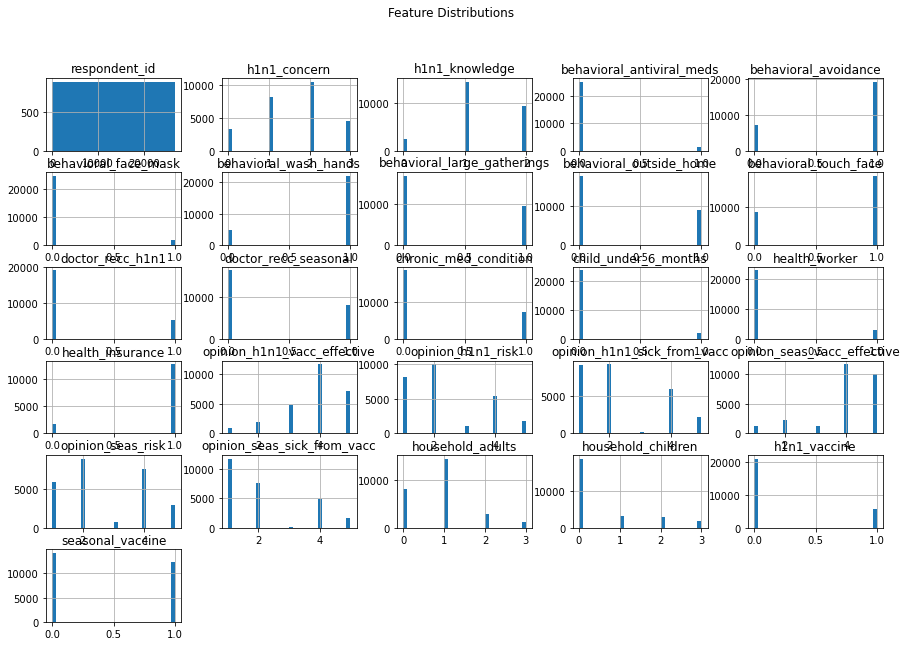

In [238]:
#Feature Distribution
df.hist(bins=30, figsize=(15, 10))
plt.suptitle("Feature Distributions")
plt.show()

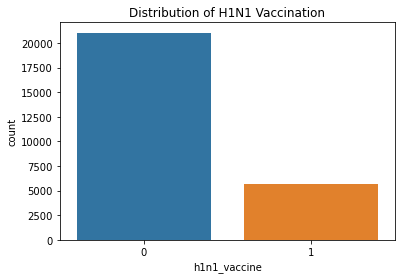

In [239]:
#Distribution of the vaccinated and non-vaccinated
sns.countplot(x='h1n1_vaccine', data=df)
plt.title('Distribution of H1N1 Vaccination')
plt.savefig('my chart.png', dpi=300 , bbox_inches= 'tight')
plt.show()

- The visualization confrims that the dataset shows an imbalance between vaccinated and non-vaccinated individuals. This is important because imbalanced data can affect model performance, particularly for metrics such as accuracy

In [240]:
df['h1n1_vaccine'].value_counts(normalize=True)

0    0.787546
1    0.212454
Name: h1n1_vaccine, dtype: float64

- Only 21.2% of individuals received the vaccine, suggesting that predicting vaccination behavior may be challenging and requires careful metric selection

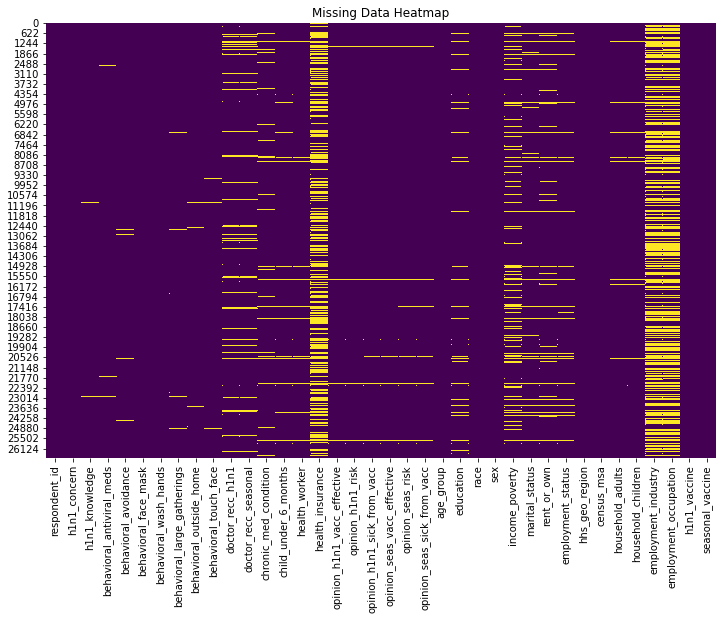

In [241]:
plt.figure(figsize=(12, 8))

# Missing Data Heatmap
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Data Heatmap")
plt.show()

- Several variables contain missing values, particularly in socio-economic features such as income, health insurance and employment. These missing values must be handled carefully to avoid bias in the model

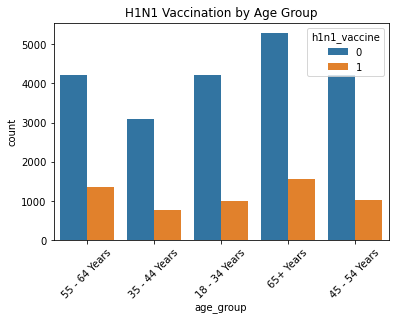

In [242]:
#Distribution of the h1n1_vaccine by age groups
sns.countplot(x='age_group', hue='h1n1_vaccine', data=df)
plt.title('H1N1 Vaccination by Age Group')
plt.xticks(rotation=45)
plt.show()

- Vaccination rates vary across age groups, with older individuals appearing more likely to receive the H1N1 vaccine. This may reflect increased health risk awareness among older populations

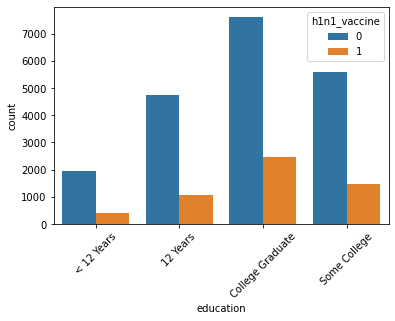

In [243]:
#Distribution of the h1n1_vaccine by level of education
sns.countplot(x='education', hue='h1n1_vaccine', data=df)
plt.xticks(rotation=45)
plt.show()

- College graduates are more likely to receive the h1n1_vaccine
- Education level appears to influence vaccination behavior, possibly due to differences in health awareness

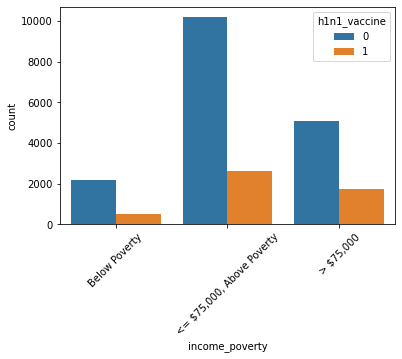

In [244]:
#Distribution of the h1n1_vaccine based on their income
sns.countplot(x='income_poverty', hue='h1n1_vaccine', data=df)
plt.xticks(rotation=45)
plt.show()

- Socioeconomic status may play a role in vaccination uptake, with higher-income individuals potentially having better access to healthcare thus are more likely to receive the h1n1_vaccine

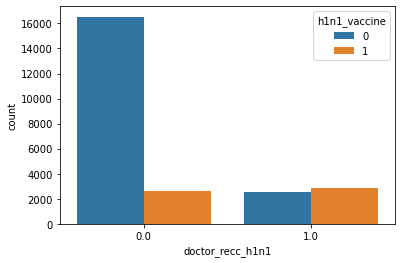

In [245]:
#Distribution of the h1n1_vaccine based on the recommendation of the doctors
sns.countplot(x='doctor_recc_h1n1', hue='h1n1_vaccine', data=df)
plt.show()

- Doctor recommendation appears to be a strong predictor of vaccination, indicating that healthcare professionals play a critical role in influencing patient decisions.

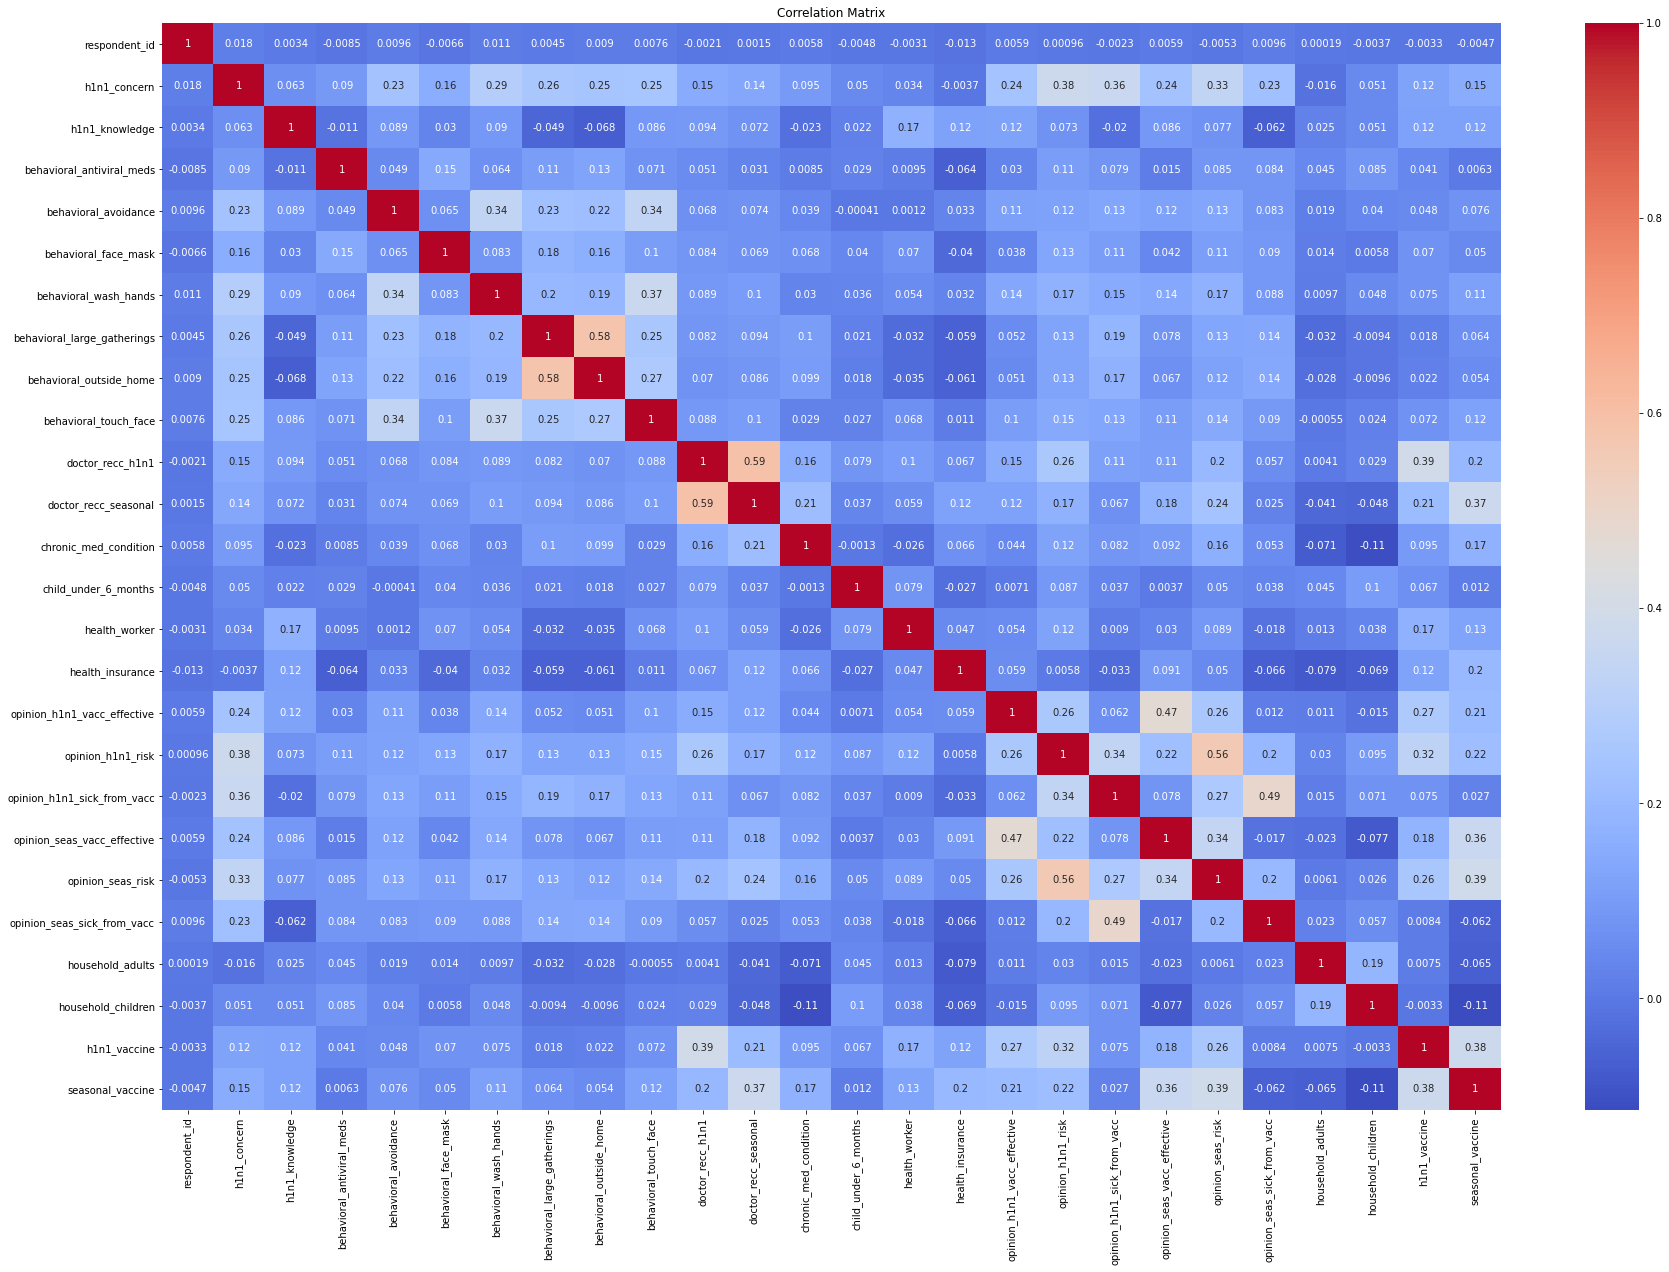

In [246]:
# Check for correlations between numerical feature and plotting a heatmap 

corr_matrix = df.corr()
plt.figure(figsize=(30, 20))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm' )
plt.title("Correlation Matrix")

plt.show()


- While correlation does not imply causation, it provides an initial indication of which features may be useful for predictive modeling.

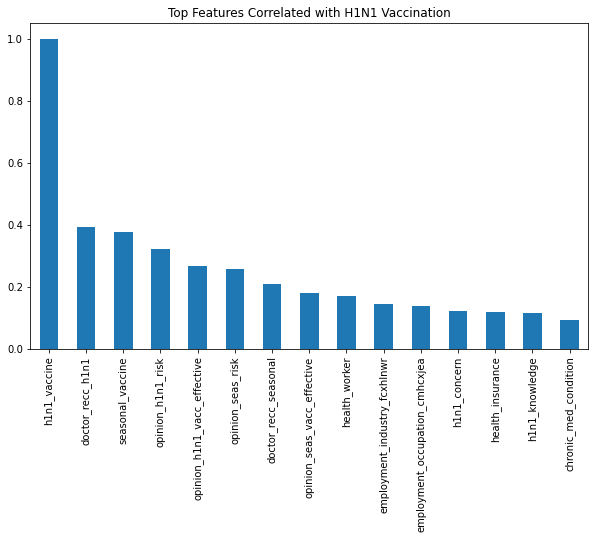

In [247]:
#Plotting the features with the highest correlation in regard to the h1n1_vaccine feature
df_encoded = pd.get_dummies(df, drop_first=True)
corr_target = df_encoded.corr()['h1n1_vaccine'].sort_values(ascending=False)

plt.figure(figsize=(10,6))
corr_target.head(15).plot(kind='bar')
plt.title('Top Features Correlated with H1N1 Vaccination')
plt.show()

## 5. Data Preparation

Missing values were handled using:
- Median imputation for numerical variables
- Mode imputation for categorical variables

Categorical variables were encoded using one-hot encoding.

The dataset was split into training and testing sets, and numerical features were scaled to improve model performance.

In [248]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())

- Missing numerical values were imputed using the median rather than the mean to reduce the impact of outliers and preserve the underlying distribution of the data.

In [249]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

- All missing values were handled prior to modeling to ensure the dataset contained no NaN values, as machine learning models such as Logistic Regression cannot process missing data.

In [250]:
X = df_encoded.drop(['h1n1_vaccine', 'seasonal_vaccine'], axis=1)
y = df_encoded['h1n1_vaccine']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [251]:
#filling values that turned to 0 after encoding
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())

In [252]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

- Since the dataset contains several categorical features/clumns such as **age group** , the model is unable to directly process that data thus one-hot encoding was ysed to transform these variables into a numerical format.

- One-hot encoding creates binary columns for each category, allowing the model to interpret categorical information without introducing unintended ordinal relationships between categories.

- Scaling/Feature scaling was applied to the numerical data using standardization (StandardScaler), which transforms the data to have a mean of 0 and a standard deviation of 1.

- Scaling is particularly important for models like Logistic Regression, which are sensitive to the magnitude of input features. Without scaling, features with larger values could disproportionately influence the model’s predictions.

- It is important to note that scaling was applied after splitting the data into training and testing sets. The scaler was fitted only on the training data and then applied to the test data to prevent data leakage and ensure a fair evaluation of model performance.

Proper preprocessing ensures that:
- The model can effectively interpret all features
- No feature dominates due to scale differences
- The model converges more efficiently during training

These steps help improve model performance and ensure more reliable and interpretable results.

### 6. MODELLING ###

### 6.1 Logistic Regression (Baseline)

- A Logistic Regression model was used as the baseline due to its simplicity and interpretability.

In [253]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [254]:
y_pred = model.predict(X_test_scaled)

In [255]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.95      0.90      4212
           1       0.70      0.43      0.53      1130

    accuracy                           0.84      5342
   macro avg       0.78      0.69      0.72      5342
weighted avg       0.83      0.84      0.83      5342



## Baseline Model Insights (Logistic Regression)

- The baseline Logistic Regression model achieves an overall accuracy of 84%, indicating strong general performance. However, a deeper look at class-level metrics reveals an imbalance in predictive performance.

- The model performs very well in identifying non-vaccinated individuals (class 0), with a high recall of 95% and precision of 86%. This suggests that the model is highly effective at correctly classifying the majority class.

- In contrast, performance on the vaccinated group (class 1) is significantly weaker. The recall of 43% indicates that the model correctly identifies less than half of the vaccinated individuals, while the precision of 70% suggests moderate reliability when it does make positive predictions.

- This imbalance in performance is likely due to class imbalance in the dataset, where non-vaccinated individuals make up a larger proportion of the data. As a result, the model is biased toward predicting the majority class.

- From a practical perspective, the low recall for vaccinated individuals is a key limitation. In the context of this problem, failing to correctly identify vaccinated individuals reduces the model’s usefulness for understanding vaccination behavior and guiding public health interventions.

- These findings highlight the need to address class imbalance and improve recall for the minority class in subsequent models.

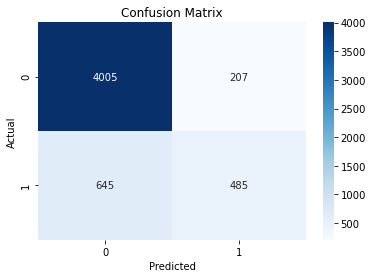

In [256]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot = True, fmt= 'd', cmap= 'Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig('my baseline confusion matrix chart.png', dpi=300 , bbox_inches= 'tight')
plt.show()

In [257]:
recall = recall_score(y_test, y_pred)
print("Recall:" , recall)

Recall: 0.42920353982300885


- The model acheives a recall of 0.4265 indicating that it was able to correctly identify 42.65% of vaccinated individuals

In [258]:
coefficients = pd.DataFrame({
    'Feature' : X.columns,
    'Coefficient' : model.coef_[0]
}).sort_values(by= 'Coefficient' , ascending=False)
coefficients.head(10)

,Feature,Coefficient
10,doctor_recc_h1n1,0.804385
16,opinion_h1n1_vacc_effective,0.613689
17,opinion_h1n1_risk,0.462503
27,age_group_65+ Years,0.223327
14,health_worker,0.215498
20,opinion_seas_risk,0.210608
26,age_group_55 - 64 Years,0.132994
33,race_White,0.107528
19,opinion_seas_vacc_effective,0.100333
32,race_Other or Multiple,0.090382


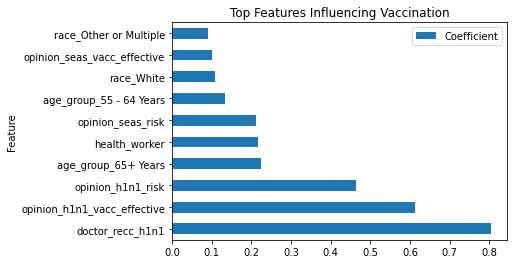

In [259]:
coefficients.head(10).plot(kind = 'barh', x= 'Feature', y = 'Coefficient')
plt.title('Top Features Influencing Vaccination')
plt.savefig('my features chart.png', dpi=300 , bbox_inches= 'tight')
plt.show()

- Features such as doctor recommendation and perceived vaccine effectiveness a very strong positive influence on vaccination likelihood 

### 6.2 Decision Tree

- A Decision Tree model was used to capture non-linear relationships in the data.

In [260]:
#making/fitting the decision tree model
tree = DecisionTreeClassifier(random_state= 42)
tree.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

In [261]:
y_pred_tree = tree.predict(X_test)

In [262]:
print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.86      0.84      0.85      4212
           1       0.44      0.47      0.46      1130

    accuracy                           0.76      5342
   macro avg       0.65      0.66      0.65      5342
weighted avg       0.77      0.76      0.77      5342



## Decision tree insights
- The model perfroms significantly better at identyfying non-vaccinated individuals than the vaccinated ones which indicates a bias towards the majority class
- The dataset is imbalanced, with significantly fewer vaccinated individuals.
- This imbalance leads to a lower recall for the vaccinated class which is critical for this problem
- The low recall for the vaccinated class indicates that the model struggles in identyfying those who took the vaccine thus limiting its usefulness for targeted public health interventions


### 6.3 Handling Class Imbalance

- To address class imbalance, class weighting was applied to both models.

- This improved the model’s ability to correctly identify vaccinated individuals. 

**Balanced Logistic Regression**


In [263]:
#fitting a balanced logistic regression
model_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')
model_balanced.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [264]:
y_pred_balanced = model_balanced.predict(X_test_scaled)

In [265]:
#Classification Report for the balanced logistic regression
print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.91      0.79      0.85      4212
           1       0.48      0.72      0.58      1130

    accuracy                           0.78      5342
   macro avg       0.70      0.76      0.71      5342
weighted avg       0.82      0.78      0.79      5342



In [266]:
print("Before Recall (Class 1):" , recall_score(y_test, y_pred))
print("After Recall (Class 1):" , recall_score(y_test, y_pred_balanced))

Before Recall (Class 1): 0.42920353982300885
After Recall (Class 1): 0.7238938053097345


- After applying the class weighting, recall for vaccinated individuals improved, indicating that the model is better at identyfying the minority class
- However, the improvement of the recall resulted to a slightly lower overall accuracy
- This highlights the trade-off between correctly identyfying minority cases and overall model performance

<function matplotlib.pyplot.show(close=None, block=None)>

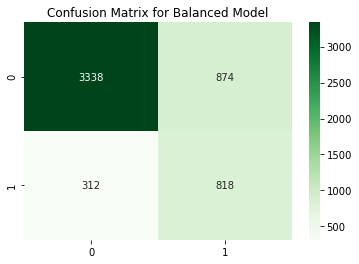

In [267]:
#Plotting a confusion matrix for the model that has been balanced
cm_balanced = confusion_matrix(y_test, y_pred_balanced)
sns.heatmap(cm_balanced, annot = True, fmt= 'd', cmap='Greens')
plt.title('Confusion Matrix for Balanced Model')
plt.show

- There is a significant increase in the number of true positives meaning our model has improved in identifying the vaccinated individuals
- The balanced model also reduces the false negatives for vaccinated individuals, meaning fewer vaccinated cases are missed

**Balanced Decision Tree**

In [268]:
#fitting the balanced decision tree model
tree_balanced = DecisionTreeClassifier(max_depth=5, min_samples_split=10, class_weight='balanced',random_state=42)
tree_balanced.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5,
                       min_samples_split=10, random_state=42)

In [269]:
y_pred_tree_balanced = tree_balanced.predict(X_test)
print(classification_report(y_test, y_pred_tree_balanced))

              precision    recall  f1-score   support

           0       0.90      0.84      0.87      4212
           1       0.52      0.66      0.58      1130

    accuracy                           0.80      5342
   macro avg       0.71      0.75      0.72      5342
weighted avg       0.82      0.80      0.81      5342



## 7. Model Evaluation



# a. Baseline Model (Logistic Regression)
**Classification report**

                 precision  recall   f1-score  support

           0       0.86      0.95      0.90      4212
           1       0.70      0.43      0.53      1130

    accuracy                           0.84      5342
   macro avg       0.78      0.69      0.72      5342
   
weighted avg       0.83      0.84      0.83      5342

**Insights**

- The  model achieves an overall accuracy of 84%, indicating strong general performance. However, there is an imbalance in predictive performance.

- The model performs very well in identifying non-vaccinated individuals (class 0), with a high recall of 95% and precision of 86%. Thus, it suggests that the model is highly effective at correctly classifying the majority class.

- In contrast, performance on the vaccinated group (class 1) is significantly weaker with a recall of 43%  and the precision of 70%.

## b. Decision tree

**Classification Report**

                 precision recall  f1-score   support

           0       0.86      0.84      0.85      4212
           1       0.44      0.47      0.46      1130

    accuracy                           0.76      5342
   macro avg       0.65      0.66      0.65      5342

weighted avg       0.77      0.76      0.77      5342

**insights**
- The model perfroms significantly better at identyfying non-vaccinated individuals than the vaccinated ones which indicates a bias towards the majority class.
- The model acheived an overall accuracy of 76% which is lower than the accuracy for the base model.
- The model does well to recognise the non-vaccinated individuals with a high recall of 84% and a precision of 86% but it is noted that the baseline model achieved better numbers.
- The performamce in recognising the vaccinated is way lower with a recall of 47% and precision of 44% ,however, this model managed to surpass the baseline model in its recall for class 1 but it was unable to do the same with its precision. 
- The baseline Model is performing better than the decision tree despite the class imbalance that was noted.

## c. Balanced Logistic Regression

**Classification Report**

                 precision  recall  f1-score  support

           0       0.91      0.79      0.85      4212
           1       0.48      0.72      0.58      1130

    accuracy                           0.78      5342
   macro avg       0.70      0.76      0.71      5342

weighted avg       0.82      0.78      0.79      5342

**Insights**
- The balanced version of the baseline model managed to acheive a recall of 79% and 91% precision for class 0.  
- The precision improved despite the drop in recall for this class and thus this model has the highest precision for class 0 so far. 
- The model achieved a recall of 72% and precision of 48% for class 1. 
- The recall for this class improved by almost 30% but with a drop in its precision. 
- The model has an accuracy of 78% which is a decrease from the baseline version.
- The model has the highest recall for class 1 . 

## d. Balanced Decision Tree

**Classification Report**

                 precision  recall  f1-score   support

           0       0.90      0.84      0.87      4212
           1       0.52      0.66      0.58      1130

    accuracy                           0.80      5342
   macro avg       0.71      0.75      0.72      5342
   
weighted avg       0.82      0.80      0.81      5342

**Insights**
- The model acheive a recall of 84% and precision of 90% for class 0.
- Unfortunately, the recall for this class didn't improve but the precision did rise.
- The model achieved a recall of 52% and precision of 66% for class 1.
- The model experienced an increase of almost 20% in its recall for this class with a related increase in its precision.
- The model has an accuracy of 80% which is an increase.
- The balanced logistic regression has the highest recall for class 1. 

## e. Model Comparison

In [270]:
#Finding the improvement in recall for both models before and after class weighing

# Logistic Regression
recall_log = recall_score(y_test, y_pred)
recall_log_bal = recall_score(y_test, y_pred_balanced)

# Decision Tree
recall_tree = recall_score(y_test, y_pred_tree)
recall_tree_bal = recall_score(y_test, y_pred_tree_balanced)

# Improvements
log_improvement = recall_log_bal - recall_log
tree_improvement = recall_tree_bal - recall_tree

print("Logistic Improvement:", log_improvement)
print("Tree Improvement:", tree_improvement)


Logistic Improvement: 0.2946902654867256
Tree Improvement: 0.18672566371681415


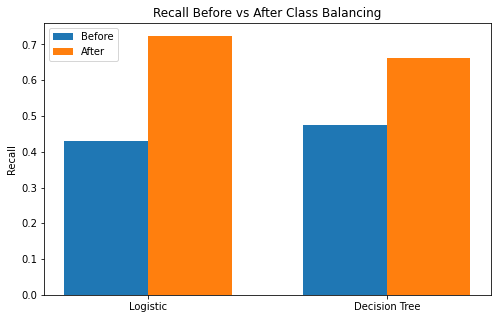

In [271]:
#Visualizing this improvement 

labels = ['Logistic', 'Decision Tree']
before = [recall_log, recall_tree]
after = [recall_log_bal, recall_tree_bal]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, before, width, label='Before')
plt.bar(x + width/2, after, width, label='After')

plt.xticks(x, labels)
plt.ylabel('Recall')
plt.title('Recall Before vs After Class Balancing')
plt.legend()
plt.savefig('my recall comparison chart.png', dpi=300 , bbox_inches= 'tight')
plt.show()

# Insights #
- The recall for the vaccinated also improved here after the class weighting thus the model is better at identifying the minority class
- A similar trade-off is also noted due to the decreased overall accuracy. 
- After applying class weighting, both models showed significant improvement in recall for vaccinated individuals. Logistic Regression demonstrated a larger improvement of approximately 30%, compared to a 22% improvement for the Decision Tree. 
- This suggests that Logistic Regression is more responsive to class imbalance adjustments in this dataset, making it more effective at identifying minority class instances.
- It is important to improve recall as it reduces the number of vaccinated individuals that are incorrectly classified. This enhances the model’s usefulness for public health interventions aimed at understanding vaccination behavior.
- **Final Model Selection:** The **balanced Logistic Regression model** provides the best performance in terms of recall, making it the most suitable model for this problem where identifying vaccinated individuals is a priority.

## f. ROC Curve and AUC

- To further evaluate model performance beyond recall, the Receiver Operating Characteristic (ROC) curve and Area Under the Curve (AUC) score were used.

- The ROC curve illustrates the trade-off between the true positive rate (recall) and the false positive rate across different classification thresholds. 
- The AUC provides a single metric summarizing the model’s ability to distinguish between classes.

In [272]:
# To compute ROC and AUC we use probabilities 
# Logistic Regression (balanced)
y_prob_log = model_balanced.predict_proba(X_test_scaled)[:, 1]

# Decision Tree (balanced)
y_prob_tree = tree_balanced.predict_proba(X_test)[:, 1]

In [273]:
#Computing the ROC and AUC

# Logistic Regression
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
auc_log = auc(fpr_log, tpr_log)

# Decision Tree
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)
auc_tree = auc(fpr_tree, tpr_tree)

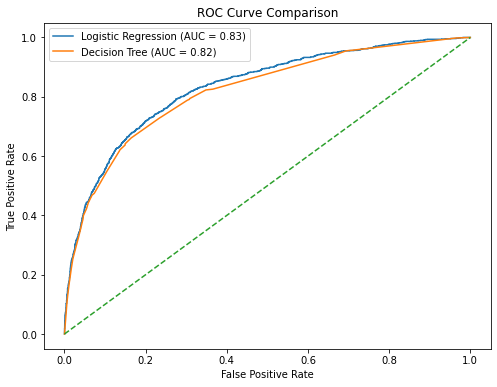

In [274]:


plt.figure(figsize=(8,6))

plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {auc_log:.2f})')
plt.plot(fpr_tree, tpr_tree, label=f'Decision Tree (AUC = {auc_tree:.2f})')

# Diagonal line (random model)
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.savefig('my ROC Curve chart.png', dpi=300 , bbox_inches= 'tight')
plt.show()

**Insights**

- The ROC curve shows the trade-off between true positive rate and false positive rate for both models. 
- Although recall was the primary evaluation metric, the ROC-AUC score provides a broader view of model performance.
- While ROC-AUC provides an overall measure of model performance, recall remains the primary metric for this problem due to the importance of correctly identifying vaccinated individuals.
- The higher AUC for Logistic Regression suggests that it is more effective at distinguishing between vaccinated and non-vaccinated individuals across different classification thresholds

## 8. Feature Importance

Key predictors include:
- Doctor recommendation
- Perceived vaccine effectiveness
- Health-related behaviors

These findings highlight the importance of both medical advice and personal beliefs in vaccination decisions.

## 9. Conclusion

- The analysis shows that vaccination behavior is influenced by a combination of demographic, behavioral, and psychological factors.

- The balanced Logistic Regression model provided the best performance, particularly in identifying vaccinated individuals.

## 10. Recommendations

- Increase doctor-led vaccination campaigns
- Improve public trust in vaccine effectiveness
- Target groups with lower vaccination likelihood
- Use data-driven strategies to improve outreach
- Public health campaigns should focus on individuals less likely to get vaccinated

## 11. Limitations

- Class imbalance affects model performance
- Data is self-reported and may contain bias
- Some relevant variables may be missing